# CSDA STAC search for Evaluation Sites

Paul Montesano, PhD  
March 2026

In [1]:
#pip install contextily

In [2]:
#pip install matplotlib_scalebar

In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from urllib.parse import quote
import numpy as np

import sys

sys.path.append('/projects/code/csda_summaries/lib')
sys.path.append('/projects/code/geoscitools')
sys.path.append('/home/pmontesa/code/csda_summaries/lib')
sys.path.append('/home/pmontesa/code/geoscitools')

import csdalib
import staclib
import siteslib

from datetime import datetime
from multiprocessing import Pool, cpu_count
from functools import partial
from tqdm import tqdm
import importlib

/opt/conda/envs/pangeo/lib/python3.12/site-packages/osgeo/osr.py:410: FutureWarning: Neither osr.UseExceptions() nor osr.DontUseExceptions() has been explicitly called. In GDAL 4.0, exceptions will be enabled by default.
  warnings.warn(


## Evaluation Sites

In [10]:
# Define your spreadsheet ID and sheet name
SPREADSHEET_ID = '13MrpqFtAOqQY9WdW9lHNsqjCbG-e3VQkEDbHOGIKa6k'
BUF_KM = 3

#### Read in sites database

In [11]:
SHEET_NAME = 'Evaluation Sites' # The name of the specific tab

# 2. Encode the sheet name for safe use in a URL
ENCODED_SHEET_NAME = quote(SHEET_NAME)

# 3. Construct the full URL using the gviz/tq endpoint
url = f"https://docs.google.com/spreadsheets/d/{SPREADSHEET_ID}/gviz/tq?tqx=out:csv&sheet={ENCODED_SHEET_NAME}"

# 4. Use pandas to read the CSV data directly from the URL
try:
    sites = pd.read_csv(url)
    sites['Site Name'] = sites['Site Name abbrev'].str.rstrip()
    #sites = sites[sites['Site Name'] != 'Sicily'] # Sicily site is same as Catania
    
except Exception as e:
    print(f"An error occurred: {e}")

# Get only Priority Sites
sites = sites[sites['Priority Level'] != 'unknown']

# Get only Priority Sites = high
sites = sites[sites['Priority Level'] == 'high']

# Get the list of columns to drop
cols_to_drop = sites.columns[sites.columns.str.contains('Unnamed')]
sites = sites.drop(columns=cols_to_drop)

### Create site AOIs

In [12]:
custom_geojson_dict = {
    'PICS Libya-4': '/explore/nobackup/projects/CSDA_eval/sites/map_1x3_MODISgrids_Libya4.geojson'
}

# Create GeoDataFrame
sites_gdf = siteslib.create_sites_gdf_with_aois(
    sites, 
    default_size_km=BUF_KM,
    custom_geojson_dict=custom_geojson_dict, 
    site_column='Site Name',
    lat_column='Latitude',
    lon_column='Longitude'
)

print(f"\n{sites_gdf.shape[0]} sites are being used to search for imagery.")

ERROR loading custom geometry for PICS Libya-4: /explore/nobackup/projects/CSDA_eval/sites/map_1x3_MODISgrids_Libya4.geojson: No such file or directory
  Using default circle buffer instead

35 sites are being used to search for imagery.


#### Comfigure site AOIs for display

In [13]:
### Buffer MORE for sites for display
BUF_KM_ADD_FOR_DISPLAY = 25
BUF_KM_TOTAL_FOR_DISPLAY = BUF_KM_ADD_FOR_DISPLAY + BUF_KM

In [14]:
sites_gdf_buf = sites_gdf.to_crs(3857).buffer(BUF_KM_ADD_FOR_DISPLAY * 1000) # add arbitrary buffer to evaluation sites for map display
sites_gdf_buf_display = gpd.GeoDataFrame(sites_gdf.drop(columns=['geometry']), geometry=sites_gdf_buf, crs=sites_gdf_buf.crs).to_crs(4326)
sites_gdf_buf_display = sites_gdf_buf_display[~(sites_gdf_buf_display.geometry.is_empty | sites_gdf_buf_display.geometry.isna())]

### Check site extents

In [15]:
sites_gdf.explore(m=sites_gdf_buf_display.explore(color='black'), color='red')

## List CSDA STAC Collections

In [16]:
import requests
from IPython.display import Markdown, display

STAC_API_URL = 'https://csdap.earthdata.nasa.gov/stac'

# Get collections
response = requests.get(f'{STAC_API_URL}/collections')
data = response.json()

collections = data.get('collections', [])

# Build markdown
markdown_output = f"# CSDA STAC Collections\n\n"
markdown_output += f"**Total Collections:** {len(collections)}\n\n"
markdown_output += "| ID | Title | Description | Temporal Coverage |\n"
markdown_output += "|:---|:---|:---|:---|\n"

for collection in collections:
    col_id = collection.get('id', 'N/A')
    title = collection.get('title', 'N/A')
    description = collection.get('description', 'N/A')
    
    # Truncate and clean description
    if description and description != 'N/A':
        description = description.replace('\n', ' ').replace('\r', '')
        if len(description) > 100:
            description = description[:100] + '...'
        description = description.replace('|', '\\|')
    
    # Get temporal extent with safe None checks
    temporal_str = 'N/A'
    try:
        extent = collection.get('extent')
        if extent and isinstance(extent, dict):
            temporal = extent.get('temporal')
            if temporal and isinstance(temporal, dict):
                intervals = temporal.get('interval', [])
                if intervals and isinstance(intervals, list) and len(intervals) > 0:
                    if intervals[0] and isinstance(intervals[0], list) and len(intervals[0]) > 0:
                        start = intervals[0][0] if intervals[0][0] else 'Unknown'
                        end = intervals[0][1] if len(intervals[0]) > 1 and intervals[0][1] else 'Present'
                        
                        # Format dates nicely
                        if isinstance(start, str) and start not in ['Unknown', 'N/A']:
                            start = start.split('T')[0]
                        if isinstance(end, str) and end not in ['Present', 'N/A']:
                            end = end.split('T')[0]
                        
                        temporal_str = f"{start} to {end}"
    except Exception as e:
        # If anything goes wrong, just leave as N/A
        pass
    
    # Create collection link
    collection_url = f"{STAC_API_URL}/collections/{col_id}"
    col_id_link = f"[{col_id}]({collection_url})"
    
    markdown_output += f"| {col_id_link} | {title} | {description} | {temporal_str} |\n"

# Display in notebook
display(Markdown(markdown_output))

# Save to file
with open('stac_collections.md', 'w') as f:
    f.write(markdown_output)

print("\n✓ Saved to stac_collections.md")

# CSDA STAC Collections

**Total Collections:** 16

| ID | Title | Description | Temporal Coverage |
|:---|:---|:---|:---|
| [geooptics](https://csdap.earthdata.nasa.gov/stac/collections/geooptics) | GeoOptics | geooptics | N/A |
| [capellaspace](https://csdap.earthdata.nasa.gov/stac/collections/capellaspace) | CapellaSpace | capellaspace | N/A |
| [desis](https://csdap.earthdata.nasa.gov/stac/collections/desis) | DESIS | Teledyne Brown Engineering, Inc – DESIS | 2018-11-21 to 2024-05-31 |
| [planet](https://csdap.earthdata.nasa.gov/stac/collections/planet) | Planet | Planet | N/A |
| [spire](https://csdap.earthdata.nasa.gov/stac/collections/spire) | Spire | Spire | N/A |
| [umbra](https://csdap.earthdata.nasa.gov/stac/collections/umbra) | Umbra | Umbra Space | 2024-01-01 to 2025-07-31 |
| [iceye](https://csdap.earthdata.nasa.gov/stac/collections/iceye) | Iceye | ICEYE US | 2019-01-01 to 2024-12-31 |
| [ghgsat](https://csdap.earthdata.nasa.gov/stac/collections/ghgsat) | GHGSat | GHGSat | 2011-01-01 to Present |
| [blacksky](https://csdap.earthdata.nasa.gov/stac/collections/blacksky) | Blacksky | blacksky | N/A |
| [pgc-earthdem](https://csdap.earthdata.nasa.gov/stac/collections/pgc-earthdem) | EarthDEM | EarthDEM | 2003-01-01 to Present |
| [maxar-sdx](https://csdap.earthdata.nasa.gov/stac/collections/maxar-sdx) | Maxar DEM | Maxar Technologies – Precision 3D | 2010-01-01 to 2025-09-29 |
| [planetiq](https://csdap.earthdata.nasa.gov/stac/collections/planetiq) | PlanetiQ | PlanetiQ | 2024-01-01 to 2024-12-31 |
| [tomorrow](https://csdap.earthdata.nasa.gov/stac/collections/tomorrow) | Tomorrow | The Tomorrow Companies Inc. | 2023-01-01 to 2025-08-15 |
| [maxar-legion](https://csdap.earthdata.nasa.gov/stac/collections/maxar-legion) | Maxar Legion | Maxar Technologies Inc. | 2024-01-01 to 2025-08-13 |
| [satellogic](https://csdap.earthdata.nasa.gov/stac/collections/satellogic) | Satellogic | Satellogic Inc. | Unknown to Present |
| [airbus](https://csdap.earthdata.nasa.gov/stac/collections/airbus) | Airbus U.S.- SAR | Airbus U.S. | 2007-01-02 to Present |



✓ Saved to stac_collections.md


### Create site dicts for all sites

In [17]:
site_dicts = staclib.create_site_dict_from_gdf(sites_gdf, site_name_field = 'Site Name')

In [18]:
site_dicts

{'Albuquerque': {'bbox': [-106.63054019720825,
   35.05496548442082,
   -106.59711722255102,
   35.08244447342852],
  'lon': -106.61382598499502,
  'lat': 35.06870561318548,
  'buffer': None,
  'geom_type': 'Polygon'},
 'Baotou': {'bbox': [109.62919607805327,
   40.85160406320536,
   109.62967792066271,
   40.85196993633672],
  'lon': 109.6294370000011,
  'lat': 40.851786999915845,
  'buffer': None,
  'geom_type': 'Polygon'},
 'Belo Horizonte': {'bbox': [-43.95764614739533,
   -19.90577241730563,
   -43.928811415375364,
   -19.87849653433831],
  'lon': -43.94323001699932,
  'lat': -19.892134797583736,
  'buffer': None,
  'geom_type': 'Polygon'},
 'Boston': {'bbox': [-71.02804038993386,
   42.35363267579147,
   -70.9907673974059,
   42.3812726998632],
  'lon': -71.00939999396033,
  'lat': 42.367453501512934,
  'buffer': None,
  'geom_type': 'Polygon'},
 'Cape Town': {'bbox': [18.4904892901448,
   -34.006829615613285,
   18.52373158122274,
   -33.979140546272674],
  'lon': 18.50711302494

# Multiprocess search across all CSDA Evaluation Sites for a vendor

### Configure search

In [20]:
COLLECTION_LIST = ['satellogic']
START_OF_COMMERCIAL_ERA = '1999-01-01'
TODAY = datetime.now().strftime('%Y-%m-%d')

# START_DATE = '2010-01-01'
# END_DATE = '2025-01-21'#'2024-10-31' # last date of data used for original Satellogic eval

# START_DATE = '2025-01-21'#'2024-10-31' # last date of data used for original Satellogic eval
# END_DATE = TODAY

START_DATE = START_OF_COMMERCIAL_ERA
END_DATE = TODAY

CSDA_EVAL_SITE_ITEMS = list(site_dicts.items())

### Multiprocess search

In [21]:
search_func = partial(staclib.stac_search_site, end_date=END_DATE, start_date=START_DATE, 
                      collections=COLLECTION_LIST
                     )
#search_func = partial(search_site, today=today, start_date='2010-01-01', collections=['maxar'])

n_processes = max(1, cpu_count() - 1)
print(f"Using {n_processes} processes to search {len(CSDA_EVAL_SITE_ITEMS)} sites\n")

# Run with progress bar
with Pool(processes=n_processes) as pool:
    results = list(tqdm(
        pool.imap(search_func, CSDA_EVAL_SITE_ITEMS),
        total=len(CSDA_EVAL_SITE_ITEMS),
        desc="Searching sites"
    ))

# Collect and report results
stac_gdf_list = []
print("\nResults by site:")
for site_name, gdf, message in results:
    print(f"  {site_name}: {message}")
    if gdf is not None:
        stac_gdf_list.append(gdf)

# Combine
if stac_gdf_list:
    stac_gdf = pd.concat(stac_gdf_list, ignore_index=True)
    print(f"\n{'='*60}")
    print(f"Total: {len(stac_gdf)} items from {stac_gdf['site_name'].nunique()} sites")
    print(f"{'='*60}")
    print("\nItems per site:")
    print(stac_gdf['site_name'].value_counts())
else:
    print("\nNo items found")
    stac_gdf = gpd.GeoDataFrame()

Using 31 processes to search 35 sites



Searching sites: 100%|██████████| 35/35 [00:01<00:00, 26.22it/s]


Results by site:
  Albuquerque: Found 8 items
  Baotou: Found 8 items
  Belo Horizonte: No items found
  Boston: No items found
  Cape Town: No items found
  Casablanca: Found 13 items
  Caspian Sea: No items found
  Catania: Found 8 items
  Crater Lake: No items found
  Cuprite: No items found
  Dublin: No items found
  Gobabeb: No items found
  Hohhot: No items found
  King Fahd Causeway: No items found
  La Crau: No items found
  Lake Pontchartrain Causeway: Found 2 items
  London: No items found
  Melbourne: No items found
  Navarre Causeway: No items found
  Old Bahia Bridge: No items found
  Phoenix: No items found
  PICS Algeria-3: No items found
  PICS Libya-1: No items found
  PICS Libya-4: Found 28 items
  Piedmont: No items found
  Railroad Valley: No items found
  Rio Gallegos: Found 3 items
  Salon-de-Provence: No items found
  Sapporo: No items found
  Suramadu Bridge: No items found
  Shadnagar: No items found
  Singapore: No items found
  Sioux Falls: No items found
  

In [22]:
stac_gdf.head()

,id,collection,datetime,geometry,bbox,gsd,created,license,platform,proj:epsg,...,asset_xml-metadata_type,asset_visual-overview_href,asset_visual-overview_type,asset_geojson-metadata_href,asset_geojson-metadata_type,asset_analytic-overview_href,asset_analytic-overview_type,asset_solar-and-viewing-angles_href,asset_solar-and-viewing-angles_type,site_name
0,20260110_215606_571_SN40_L1D_SR_MS_337320,satellogic,2026-01-10T21:56:06.571492Z,"POLYGON ((-106.59377 35.28684, -106.59424 35.2...","[-106.59957489688496, 34.8698364911617, -106.5...",0.5,2026-01-11T19:54:21.297952Z,proprietary,NewSat,32613,...,application/xml,s3://ss-ingest-prod-ingesteddata-uswest2/stora...,application/octet-stream,s3://ss-ingest-prod-ingesteddata-uswest2/stora...,application/geo+json,s3://ss-ingest-prod-ingesteddata-uswest2/stora...,application/octet-stream,s3://ss-ingest-prod-ingesteddata-uswest2/stora...,application/geo+json,Albuquerque
1,20260110_175204_412_SN37_L1D_SR_MS_337320,satellogic,2026-01-10T17:52:04.412068Z,"POLYGON ((-106.67492 35.28687, -106.67465 35.1...","[-106.67576523066485, 34.86976647199793, -106....",0.7,2026-01-11T00:01:34.631193Z,proprietary,NewSat,32613,...,application/xml,s3://ss-ingest-prod-ingesteddata-uswest2/stora...,application/octet-stream,s3://ss-ingest-prod-ingesteddata-uswest2/stora...,application/geo+json,s3://ss-ingest-prod-ingesteddata-uswest2/stora...,application/octet-stream,s3://ss-ingest-prod-ingesteddata-uswest2/stora...,application/geo+json,Albuquerque
2,20260106_213029_312_SN46_L1D_SR_MS_337320,satellogic,2026-01-06T21:30:29.312644Z,"POLYGON ((-106.63538 35.28686, -106.63579 35.2...","[-106.64623040500325, 34.869785055833724, -106...",0.5,2026-01-07T07:06:29.942217Z,proprietary,NewSat,32613,...,application/xml,s3://ss-ingest-prod-ingesteddata-uswest2/stora...,application/octet-stream,s3://ss-ingest-prod-ingesteddata-uswest2/stora...,application/geo+json,s3://ss-ingest-prod-ingesteddata-uswest2/stora...,application/octet-stream,s3://ss-ingest-prod-ingesteddata-uswest2/stora...,application/geo+json,Albuquerque
3,20241105_180508_SN50_L1D_MS_252680,satellogic,2024-11-05T18:05:08.731530Z,"POLYGON ((-106.62139 35.14234, -106.54601 35.1...","[-106.67986166058999, 34.898738753894825, -106...",0.7,2025-02-15T13:34:33.202152Z,proprietary,NewSat,32613,...,application/xml,s3://ss-ingest-prod-ingesteddata-uswest2/stora...,application/octet-stream,s3://ss-ingest-prod-ingesteddata-uswest2/stora...,application/geo+json,s3://ss-ingest-prod-ingesteddata-uswest2/stora...,application/octet-stream,s3://ss-ingest-prod-ingesteddata-uswest2/stora...,application/geo+json,Albuquerque
4,20240923_180910_SN50_L1D_MS_245154,satellogic,2024-09-23T18:09:10.129575Z,"POLYGON ((-106.604 35.24642, -106.51869 35.232...","[-106.67724190150452, 34.93891300302777, -106....",0.7,2025-02-15T13:37:50.482291Z,proprietary,NewSat,32613,...,application/xml,s3://ss-ingest-prod-ingesteddata-uswest2/stora...,application/octet-stream,s3://ss-ingest-prod-ingesteddata-uswest2/stora...,application/geo+json,s3://ss-ingest-prod-ingesteddata-uswest2/stora...,application/octet-stream,s3://ss-ingest-prod-ingesteddata-uswest2/stora...,application/geo+json,Albuquerque


#### Timeline of Satellogic acquisitions by version at sites

In [23]:
START_DATE

'1999-01-01'

In [25]:
from plotnine import *
import pandas as pd
from datetime import datetime

# Define start and end dates
start_date = pd.to_datetime('2021-01-01')
end_date = timeline_df['date'].max()

# start_date_obj = datetime.strptime(START_DATE, '%Y-%m-%d')  # adjust format as needed
start_date_obj = start_date

# Prepare data
plot_df = stac_gdf.copy()
plot_df.columns = plot_df.columns.str.replace(':', '_')

# Convert datetime to pandas datetime if it's a string
if plot_df['datetime'].dtype == 'object':
    plot_df['datetime'] = pd.to_datetime(plot_df['datetime'])

# # Filter from 2010 onwards
# plot_df = plot_df[plot_df['datetime'] >= '2010-01-01'].copy()

# Extract year-month for grouping
plot_df['year_month'] = plot_df['datetime'].dt.to_period('M').astype(str)

# Count acquisitions by year-month and version
timeline_df = plot_df.groupby(['year_month', 'satl_product_version','site_name']).size().reset_index(name='count')

# Convert year_month back to datetime for plotting
timeline_df['date'] = pd.to_datetime(timeline_df['year_month'])

# Create plot with explicit x-axis limits
p = (
    ggplot(timeline_df, aes(x='date', y='count', fill='satl_product_version')) +
    geom_col() +
    scale_x_datetime(
        limits=[start_date, end_date],
        date_breaks='3 month',
        date_labels='%Y-%m'
    ) +
    labs(
        title=f"Satellogic: acquisition timeline by product version ({start_date_obj.strftime('%Y')}-Present)",
        x='Acquisition Date',
        y='Number of Acquisitions',
        fill='Product Version'
    ) +
    theme_bw() +
    theme(
        figure_size=(12, 10),
        axis_text_x=element_text(angle=45, hjust=1),
        plot_title=element_text(size=14, weight='bold')
    )
    #+ facet_grid('satl_satellite_generation~')
    #+ facet_wrap('~satl_satellite_generation+site_name')
    + facet_wrap('~site_name', ncol=1)

)

p

NameError: name 'timeline_df' is not defined

## Plot maps of sites and their acqs (static)

#### Filter for Satellogic v2 data

In [26]:
stac_gdf['satl:satellite_generation'].unique()

array(['MarkV', 'MarkIV', nan, ''], dtype=object)

In [27]:
stac_gdf['satl:product_version'].unique()

array(['2.0.1', '1.1.2', '0.3.0'], dtype=object)

In [28]:
# Filter for version 2.*
SEARCH_STR = '2.'
if 'satl:product_version' in stac_gdf.columns:
    stac_gdf_v2 = stac_gdf[stac_gdf['satl:product_version'].str.startswith(SEARCH_STR, na=False)].copy()
    print(f"Filtered {len(stac_gdf)} items to {len(stac_gdf_v2)} with version {SEARCH_STR}*")
# else:
#     print("'satl:product_version' property not found")
#     stac_gdf_v2 = stac_gdf

# Filter for version 2.*
SEARCH_STR = '1.'
if 'satl:product_version' in stac_gdf.columns:
    stac_gdf_v1 = stac_gdf[stac_gdf['satl:product_version'].str.startswith(SEARCH_STR, na=False)].copy()
    print(f"Filtered {len(stac_gdf)} items to {len(stac_gdf_v1)} with version {SEARCH_STR}*")

Filtered 70 items to 18 with version 2.*
Filtered 70 items to 50 with version 1.*


In [29]:
stac_gdf_v2['satl:product_version'].unique()

array(['2.0.1'], dtype=object)

#### We have Satellogic data at these sites (any version)

In [30]:
print(stac_gdf.site_name.unique())

['Albuquerque' 'Baotou' 'Casablanca' 'Catania'
 'Lake Pontchartrain Causeway' 'PICS Libya-4' 'Rio Gallegos']


#### We have Satellogic version 2 data only at these sites

In [31]:
print(f"Satellogic v2.x (n={len(stac_gdf_v2)} acquisitions) available for {len(stac_gdf_v2.site_name.unique())} CSDA Evaluation Sites:\n{stac_gdf_v2.site_name.unique()}")

Satellogic v2.x (n=18 acquisitions) available for 6 CSDA Evaluation Sites:
['Albuquerque' 'Baotou' 'Casablanca' 'Catania' 'PICS Libya-4'
 'Rio Gallegos']


## Overview map of STAC collections at evaluation sites

/opt/conda/envs/pangeo/lib/python3.12/site-packages/contextily/tile.py:662: UserWarning: The inferred zoom level of 27 is not valid for the current tile provider (valid zooms: 0 - 16).


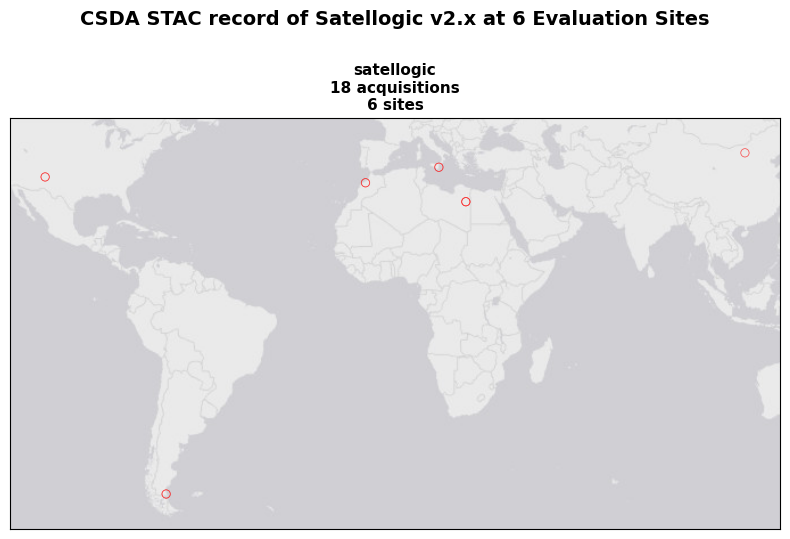

In [32]:
fig = staclib.plot_collections_map(stac_gdf_v2, show_stats=True, 
                                   suptitle=f"CSDA STAC record of Satellogic v2.x at {len(stac_gdf_v2.site_name.unique())} Evaluation Sites")
plt.show()

In [34]:
stac_gdf_v2.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 18 entries, 0 to 69
Data columns (total 57 columns):
 #   Column                               Non-Null Count  Dtype   
---  ------                               --------------  -----   
 0   id                                   18 non-null     object  
 1   collection                           18 non-null     object  
 2   datetime                             18 non-null     object  
 3   geometry                             18 non-null     geometry
 4   bbox                                 18 non-null     object  
 5   gsd                                  18 non-null     float64 
 6   created                              18 non-null     object  
 7   license                              18 non-null     object  
 8   platform                             18 non-null     object  
 9   proj:epsg                            18 non-null     int64   
 10  providers                            18 non-null     object  
 11  instruments       

In [33]:
stac_gdf_v2[stac_gdf_v2.site_name == 'Rio Gallegos']

,id,collection,datetime,geometry,bbox,gsd,created,license,platform,proj:epsg,...,asset_xml-metadata_type,asset_visual-overview_href,asset_visual-overview_type,asset_geojson-metadata_href,asset_geojson-metadata_type,asset_analytic-overview_href,asset_analytic-overview_type,asset_solar-and-viewing-angles_href,asset_solar-and-viewing-angles_type,site_name
67,20260310_144237_878_SN26_L1D_SR_MS_337319,satellogic,2026-03-10T14:42:37.878775Z,"POLYGON ((-69.31683 -51.41182, -69.31651 -51.4...","[-69.31993008851884, -51.82884320884462, -69.2...",0.5,2026-03-10T21:30:21.105001Z,proprietary,NewSat,32719,...,application/xml,s3://ss-ingest-prod-ingesteddata-uswest2/stora...,application/octet-stream,s3://ss-ingest-prod-ingesteddata-uswest2/stora...,application/geo+json,s3://ss-ingest-prod-ingesteddata-uswest2/stora...,application/octet-stream,s3://ss-ingest-prod-ingesteddata-uswest2/stora...,application/geo+json,Rio Gallegos
68,20260207_142040_808_SN51_L1D_SR_MS_337319,satellogic,2026-02-07T14:20:40.808530Z,"POLYGON ((-69.22387 -51.41182, -69.22376 -51.4...","[-69.22560985909732, -51.82885848996909, -69.1...",0.5,2026-02-07T19:52:45.139774Z,proprietary,NewSat,32719,...,application/xml,s3://ss-ingest-prod-ingesteddata-uswest2/stora...,application/octet-stream,s3://ss-ingest-prod-ingesteddata-uswest2/stora...,application/geo+json,s3://ss-ingest-prod-ingesteddata-uswest2/stora...,application/octet-stream,s3://ss-ingest-prod-ingesteddata-uswest2/stora...,application/geo+json,Rio Gallegos
69,20260128_145053_624_SN48_L1D_SR_MS_337319,satellogic,2026-01-28T14:50:53.624144Z,"POLYGON ((-69.26276 -51.41196, -69.26188 -51.4...","[-69.26805411415928, -51.8288688095266, -69.16...",0.5,2026-01-28T20:35:56.791940Z,proprietary,NewSat,32719,...,application/xml,s3://ss-ingest-prod-ingesteddata-uswest2/stora...,application/octet-stream,s3://ss-ingest-prod-ingesteddata-uswest2/stora...,application/geo+json,s3://ss-ingest-prod-ingesteddata-uswest2/stora...,application/octet-stream,s3://ss-ingest-prod-ingesteddata-uswest2/stora...,application/geo+json,Rio Gallegos


In [130]:
import importlib

In [131]:
importlib.reload(csdalib)

<module 'csdalib' from '/home/pmontesa/code/csda_summaries/lib/csdalib.py'>

### Plot site maps for Satellogic v2 acquisitions

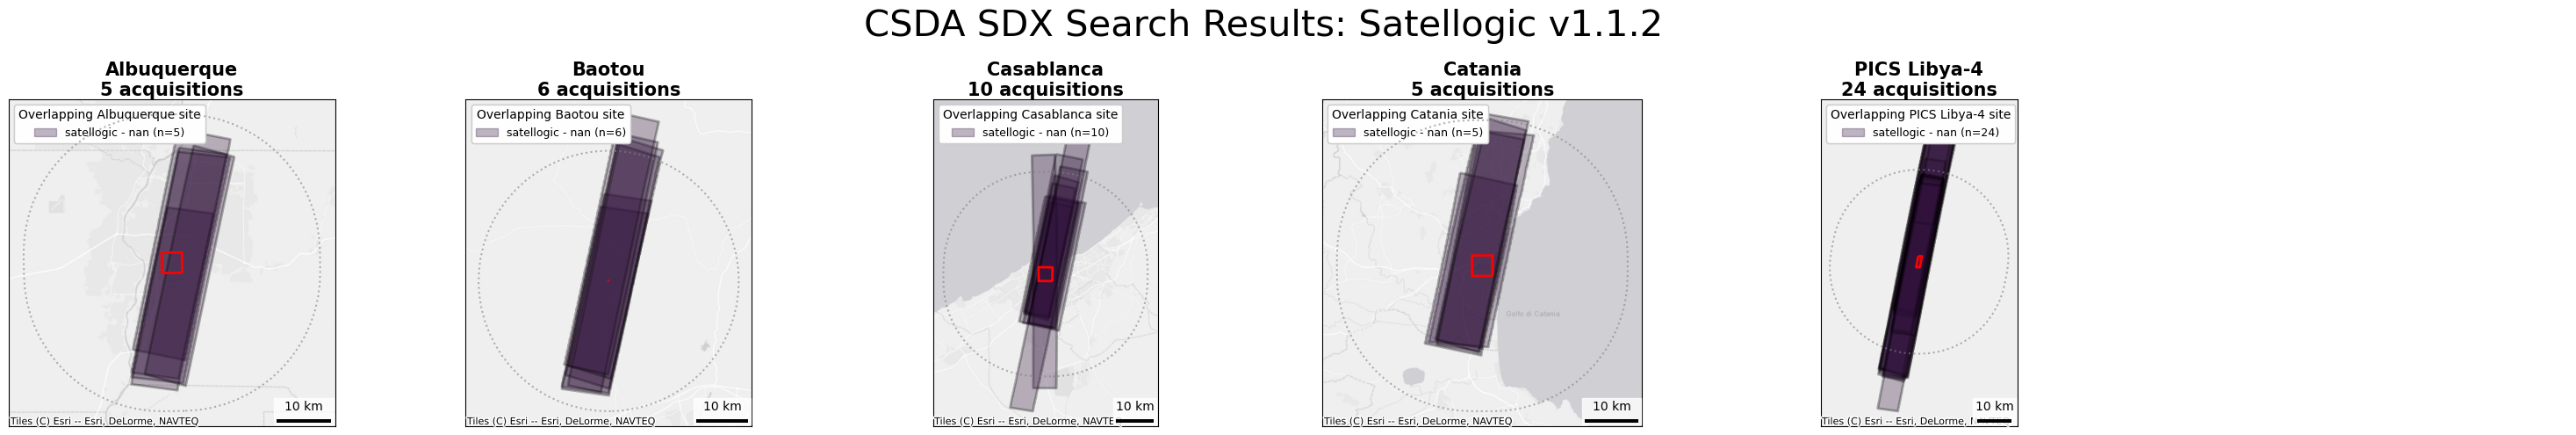

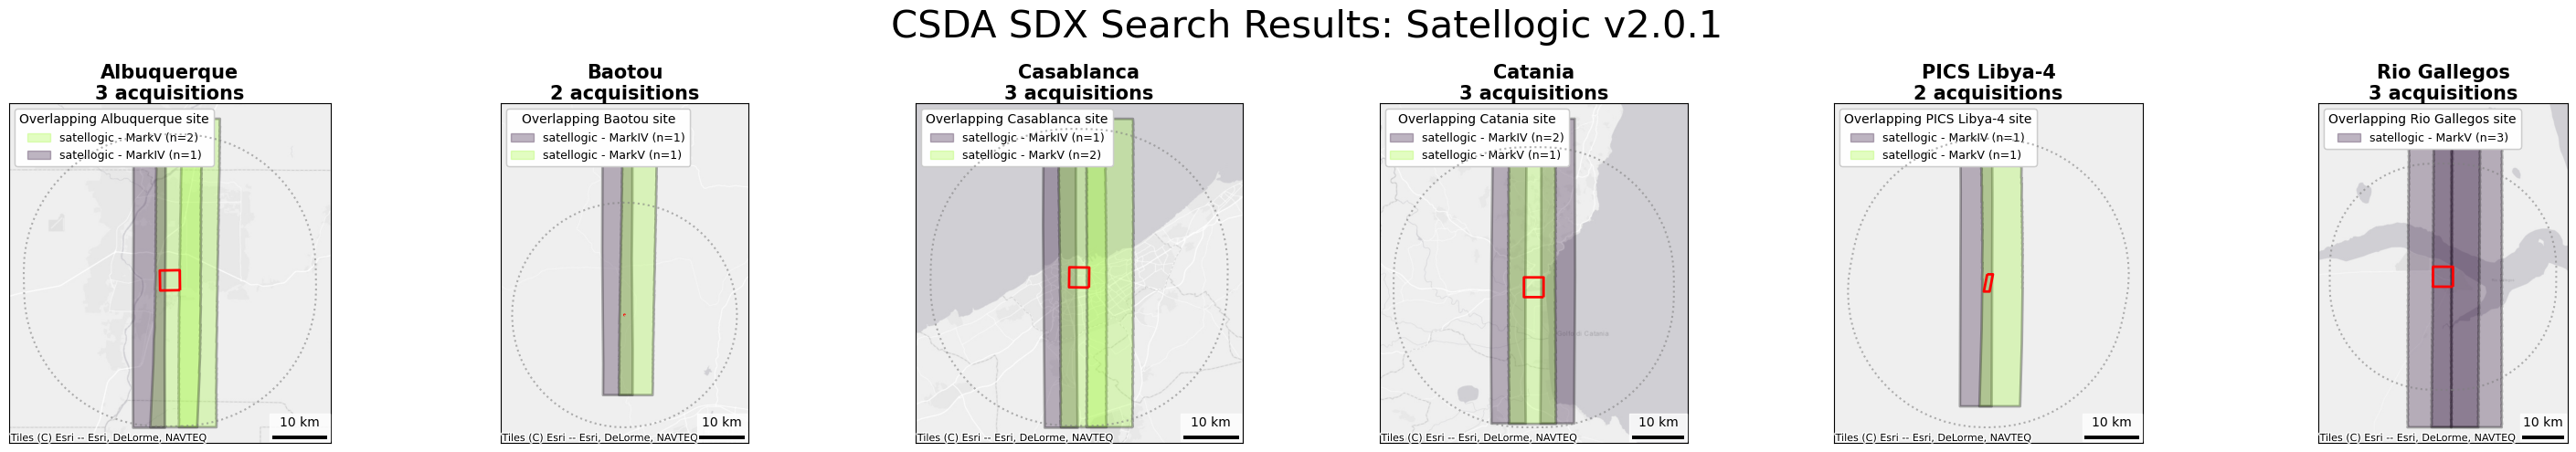

In [132]:
# Define gdf to plot

for gdf_to_plot in [stac_gdf_v1, stac_gdf_v2]:
    
    # Define sites to plot
    sites_to_plot = sorted([site for site in gdf_to_plot.site_name.unique() if site != 'Not CSDA Eval Site'])
    
    # Create grid
    n_sites = len(sites_to_plot)
    n_cols = 6
    n_rows = int(np.ceil(n_sites / n_cols))
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols,5 * n_rows))
    
    # Flatten axes
    if n_sites == 1:
        axes = [axes]
    else:
        axes = axes.flatten() if n_rows > 1 else [axes] if n_cols == 1 else axes
    
    # Plot each site
    for idx, site_name in enumerate(sites_to_plot):
        csdalib.plot_site_coverage(site_name, 
                          gdf_to_plot, 
                          sites_gdf, 
                          BUF_KM, 
                          BUF_KM_TOTAL_FOR_DISPLAY,
                          sites_buf_gdf=sites_gdf_buf_display,
                          site_name_field = 'site_name',
                                   
                            # Satellogic
                            id_field = 'id', 
                            affiliation_field = 'collection',
                            constellation_field = 'satl:satellite_generation',
                                   
                          ax=axes[idx])  # Pass the axis here
    
    # Hide unused subplots
    for idx in range(n_sites, len(axes)):
        axes[idx].axis('off')
    plt.suptitle(f"CSDA SDX Search Results: Satellogic v{gdf_to_plot['satl:product_version'].unique()[0]}", size=30 )
    plt.tight_layout()
    plt.show()

## Heatmaps provides info on amount of overlap at a site

#### static, all sites for each collection

Calculating global count range...
Global count range: 1 - 4


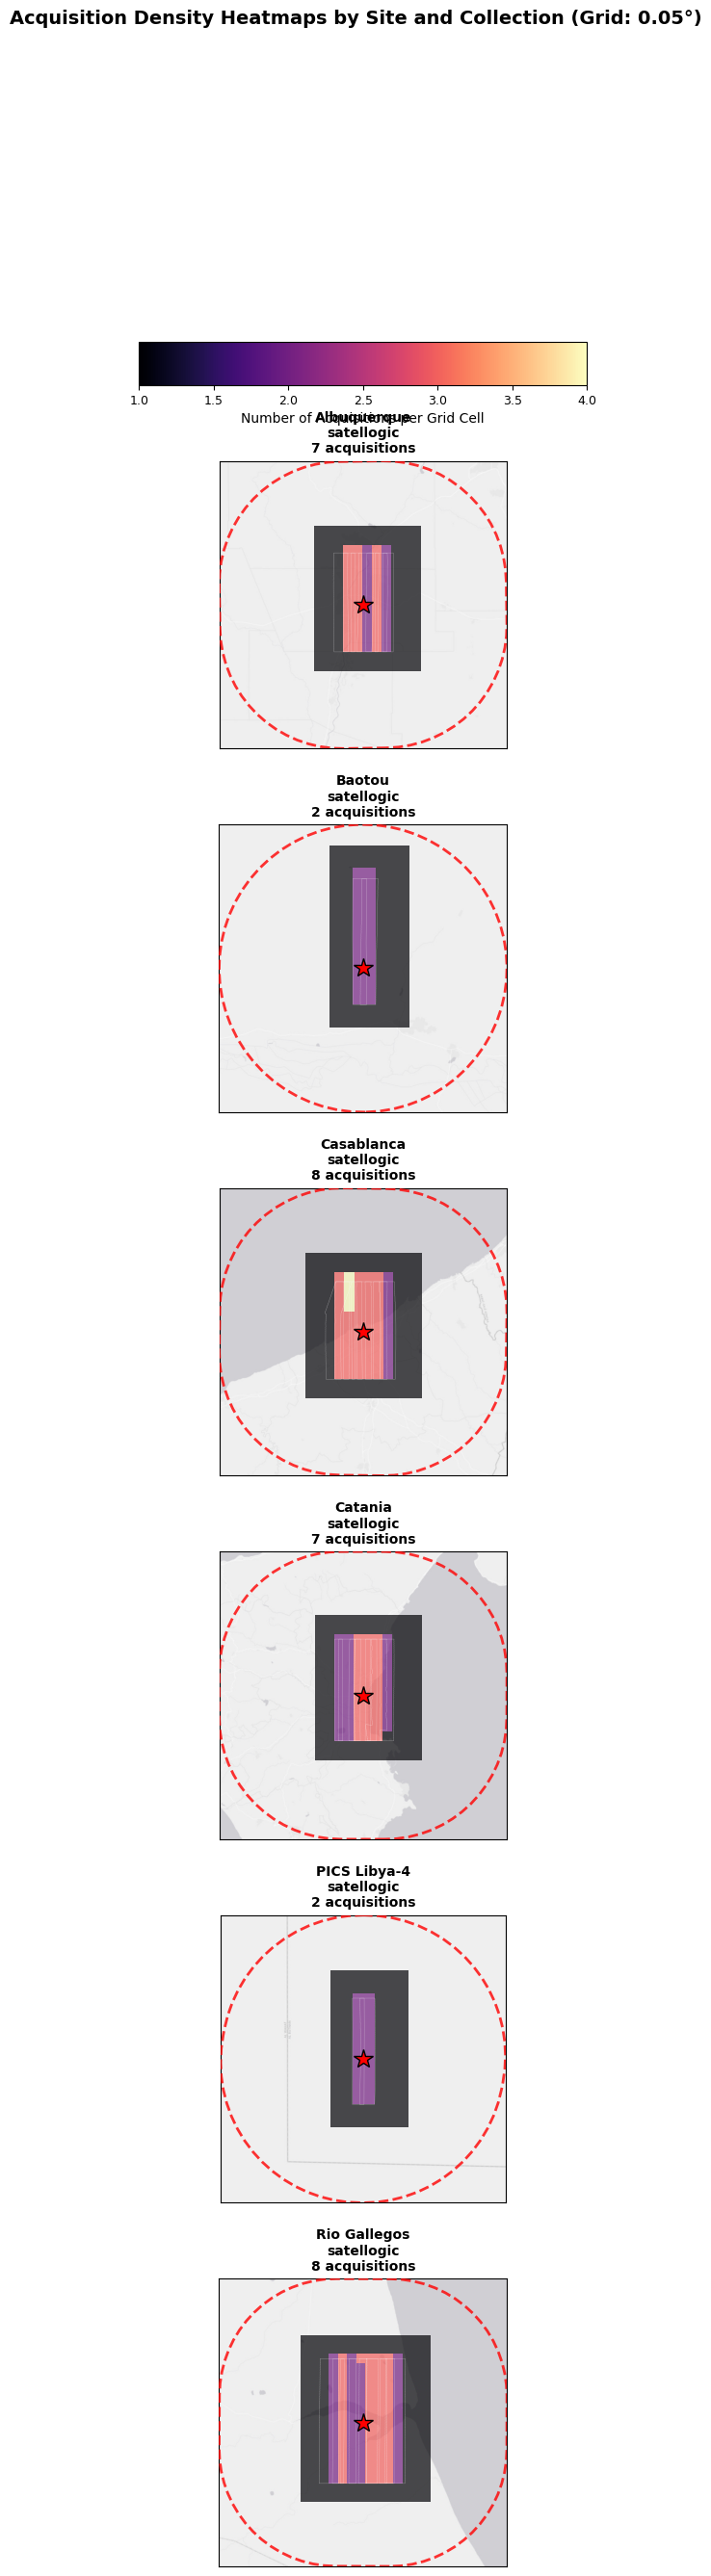

In [167]:
# Use it
all_grids, fig = staclib.create_acquisition_heatmap_multi(
    stac_gdf_v2,
    sites_gdf,
    sites_gdf_buf_display,
    site_name_field='site_name',
    site_name_field_sites='Site Name',
    # collections=['planet', 'satellogic'],
    # sites=['PICS Libya-4', 'Casablanca'],
    collections=['satellogic'],
    sites=None,
    grid_size=0.05,
    cmap='magma'
)

plt.show()

#### interactive for 1 site, collection

In [37]:
m, grid_gdf = staclib.create_interactive_heatmap(
    stac_gdf_v2,
    collection_name='satellogic',
    grid_size=0.01,
    cmap='magma',
    site_name='Casablanca'
)

# m.save('libya4_satellogic_heatmap.html')
m

Creating heatmap for 2 acquisitions
Grid cells with data: 690
Acquisition count range: 1 - 2


## Read an image on-the-fly and plot

In [35]:
stac_gdf.filter(like='asset').columns

Index(['asset_cloud_href', 'asset_cloud_type', 'asset_visual_href',
       'asset_visual_type', 'asset_preview_href', 'asset_preview_type',
       'asset_analytic_href', 'asset_analytic_type', 'asset_footprint_href',
       'asset_footprint_type', 'asset_thumbnail_href', 'asset_thumbnail_type',
       'asset_vrt_cloud_href', 'asset_vrt_cloud_type', 'asset_vrt_visual_href',
       'asset_vrt_visual_type', 'asset_toa-factors_href',
       'asset_toa-factors_type', 'asset_vrt_analytic_href',
       'asset_vrt_analytic_type', 'asset_xml-metadata_href',
       'asset_xml-metadata_type', 'asset_visual-overview_href',
       'asset_visual-overview_type', 'asset_geojson-metadata_href',
       'asset_geojson-metadata_type', 'asset_analytic-overview_href',
       'asset_analytic-overview_type', 'asset_solar-and-viewing-angles_href',
       'asset_solar-and-viewing-angles_type'],
      dtype='object')

#### How can I read and plot these TIF files like I do those that I find on Earthdata?

In [40]:
stac_gdf.asset_vrt_analytic_href.to_list()[0:5]

['s3://ss-ingest-prod-ingesteddata-uswest2/storage-ss-ingest-prod-ingesteddata-uswest2/satellogic/2026/01/10/20260110_175204_412_SN37_L1D_SR_MS_337320/rasters/20260110_175204_412_SN37_L1D_SR_MS_TOA_0.tif',
 's3://ss-ingest-prod-ingesteddata-uswest2/storage-ss-ingest-prod-ingesteddata-uswest2/satellogic/2026/01/06/20260106_213029_312_SN46_L1D_SR_MS_337320/rasters/20260106_213029_312_SN46_L1D_SR_MS_TOA_0.tif',
 's3://ss-ingest-prod-ingesteddata-uswest2/storage-ss-ingest-prod-ingesteddata-uswest2/satellogic/2024/11/05/20241105_180508_SN50_L1D_MS_252680/rasters/20241105_180508_SN50_L1D_MS_TOA_0.tif',
 's3://ss-ingest-prod-ingesteddata-uswest2/storage-ss-ingest-prod-ingesteddata-uswest2/satellogic/2024/09/23/20240923_180910_SN50_L1D_MS_245154/rasters/20240923_180910_SN50_L1D_MS_TOA_0.tif',
 's3://ss-ingest-prod-ingesteddata-uswest2/storage-ss-ingest-prod-ingesteddata-uswest2/satellogic/2024/09/23/20240923_180612_SN48_L1D_MS_245154/rasters/20240923_180612_SN48_L1D_MS_TOA_0.tif']